### Testing space for uMux model

In [4]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import sys
import os
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../../..'))

from source.include.components import *
from source.include.circuits import *
from source.include.helpers import *

from resonator_fitting.include import circle_fitting as cf
from resonator_fitting.include import resonance_fitting as rf
from resonator_fitting.include import all_resonances as ar


In [5]:

loaded_data = np.loadtxt('../source/data/NIST_full_s21.txt', dtype=complex)

freqs_loaded = np.real(loaded_data[:, 0])
s21_loaded = loaded_data[:, 1]
s21_db_loaded = np.abs(s21_loaded) 
s21_phase = np.angle(s21_loaded)
s21_logMag = 20*np.log10(s21_db_loaded)
s21_logMag = s21_logMag-np.max(s21_logMag)



In [6]:
data = np.load('../source/data/flux_response_params.npz')
print(data)
ibias = data['ibias']
I0fits = data['I0fits']
Minfits = data['Minfits']
Mcfits = data['Mcfits']
fbfits = data['fbfits']
lambfits = data['lambfits']


NpzFile '../source/data/flux_response_params.npz' with keys: ibias, I0fits, Minfits, Mcfits, fbfits...


In [7]:
meas_flux = np.load('../source/data/measured_flux_response.npz')
ibias = meas_flux['ibias']
dfs = meas_flux['freqs']

[0.33885284 0.33940077 0.33852331 0.33757032 0.35064417 0.34215783
 0.33089798 0.34418317 0.3373858  0.33670734 0.35075582 0.3482572
 0.34405112 0.36022868 0.34773932 0.34516538 0.3612588  0.34383536
 0.31580407 0.34860216 0.36138298 0.32983208 0.34547118 0.35156237
 0.35594035 0.37260192 0.33849043 0.35271267 0.35651304 0.32956951
 0.35623795 0.35393699]


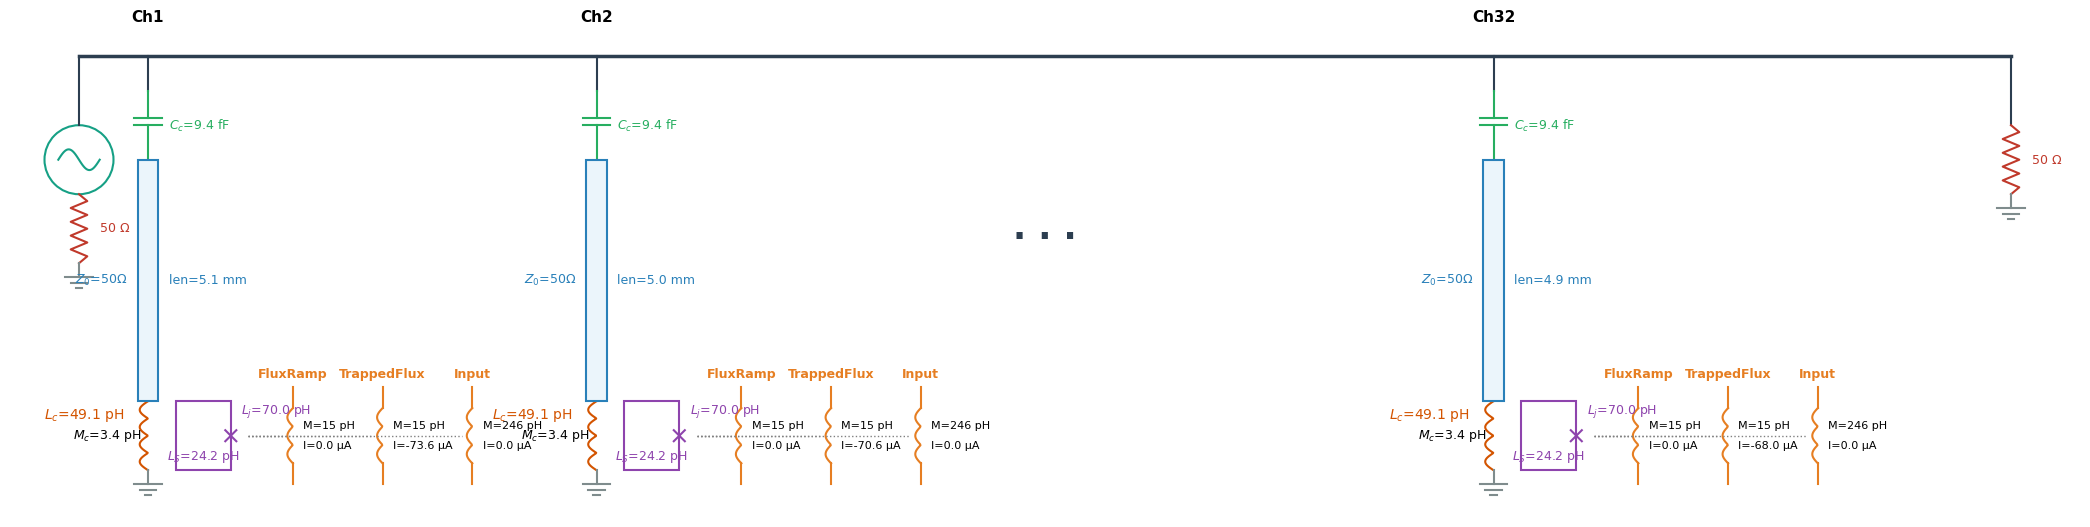

In [8]:

circle_params = np.loadtxt('../source/data/NIST_full_params.txt', dtype=float)

VNA = VNA_Simulator(z0=50)

squids = []
num_channels = 32
print(lambfits)

for i in range(num_channels):
    squid_ch = SQUID(L_j=70e-12, L_s=24.2e-12, lamb=None, phi_ext=0.0) 
    squid_ch.add_flux_line("FluxRamp", M=15e-12, initial_current=0.0)
    squid_ch.add_flux_line("TrappedFlux", M=15e-12, initial_current=0.0)
    squid_ch.add_flux_line("Input", M=246e-12)   
    
    # print("lambda fit:", lambfits[i])
    # print("M_fr:", Minfits[i])
    # print("M_c:", Mcfits[i])
    # print("I_0:", I0fits[i])
    # print("fb:", fbfits[i])
    
    # squid_ch = SQUID(L_j=24.2e-12/lambfits[i], L_s=24.2e-12, lamb=None, phi_ext=0.0) 
    # squid_ch.add_flux_line("FluxRamp", M=Minfits[i], initial_current=I0fits[i])
    # squid_ch.add_flux_line("TrappedFlux", M=15e-12, initial_current=0.0)
    # squid_ch.add_flux_line("Input", M=246e-12)   
    
    ind_ch = Inductor(49.1e-12)
    tuned_L_ch = ScreenedInductor(primary_inductor=ind_ch, screening_device=squid_ch, M=3.4e-12)
    squids.append(squid_ch)


    circ_fit = np.copy(circle_params[i]) 
    circ_fit[2] = circ_fit[2] + fbfits[i] 
    Qr, Qc = circle_params[i][3],circle_params[i][4]
    
    length, Cc_val, Qi_val = extract_physical_params(circ_fit, tuned_L_ch, Cc_in=9.4e-15)


    squid_ch.set_current("TrappedFlux", I0fits[i])

    cap_ch = Capacitor(C=Cc_val)
    phys_res = Resonator(length=length, load=tuned_L_ch, v_p=1.15e8, Qi=Qi_val, Qc=Qc, Qr = Qr)

    channel = Channel(name=f"Ch{i+1}") 
    channel.add(cap_ch)
    channel.add(phys_res)

    
    
    VNA.add(channel, 'shunt')

VNA.draw_schematic(use_color=True, max_draw=1)

(2000, 2, 2)


c:\Users\QTSFm\OneDrive\Desktop\uMux_Sim\Microwave-Multiplexing\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\QTSFm\OneDrive\Desktop\uMux_Sim\Microwave-Multiplexing\.venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


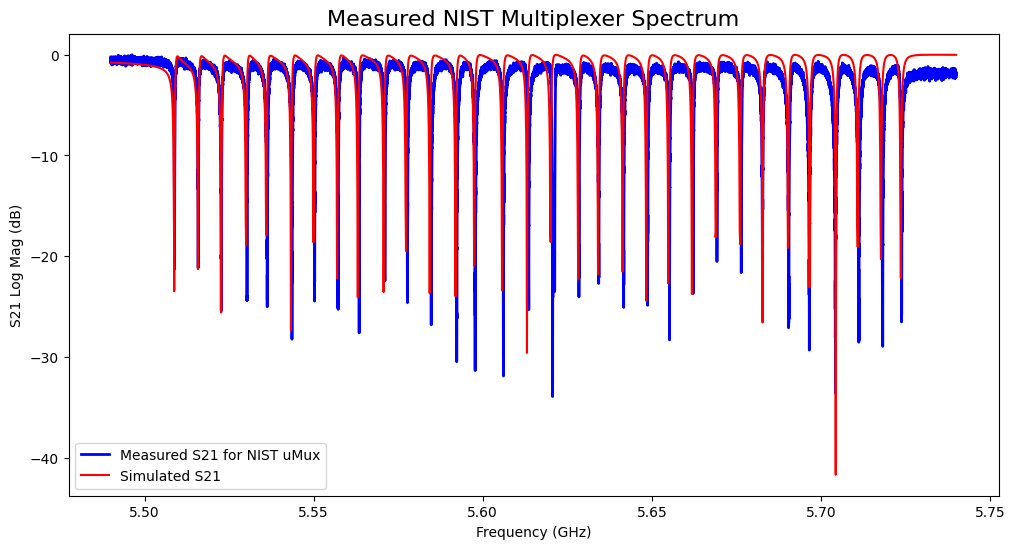

In [9]:
freqs = np.linspace(np.min(freqs_loaded),np.max(freqs_loaded),2000)
S = VNA.get_s_matrix(freqs)

plt.figure(figsize=(12,6))
plt.plot(freqs_loaded*1e-9, s21_logMag,markersize = 0.5, color = 'b',label = "Measured S21 for NIST uMux", linewidth = 2)
plt.plot(freqs*1e-9, 20*np.log10(S[1,0]), color = 'r', label = "Simulated S21")
plt.xlabel("Frequency (GHz)")
plt.ylabel("S21 Log Mag (dB)")
plt.title("Measured NIST Multiplexer Spectrum", fontsize = 16)

plt.legend()
# plt.xlim([5.6e9,5.61e9])
plt.show()



<>:56: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:56: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
C:\Users\QTSFm\AppData\Local\Temp\ipykernel_263180\1675858325.py:56: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  x_axis_label = "Input Flux / $\Phi_0$"


--- Running simulation for P_rf = -50.0 dBm ---
(2000, 2, 2)
   Tracking complete for -50.0 dBm.
--- Running simulation for P_rf = -51.05263157894737 dBm ---
(2000, 2, 2)
   Tracking complete for -51.05263157894737 dBm.
--- Running simulation for P_rf = -52.10526315789474 dBm ---
(2000, 2, 2)
   Tracking complete for -52.10526315789474 dBm.
--- Running simulation for P_rf = -53.1578947368421 dBm ---
(2000, 2, 2)
   Tracking complete for -53.1578947368421 dBm.
--- Running simulation for P_rf = -54.21052631578947 dBm ---
(2000, 2, 2)
   Tracking complete for -54.21052631578947 dBm.
--- Running simulation for P_rf = -55.26315789473684 dBm ---
(2000, 2, 2)
   Tracking complete for -55.26315789473684 dBm.
--- Running simulation for P_rf = -56.31578947368421 dBm ---
(2000, 2, 2)
   Tracking complete for -56.31578947368421 dBm.
--- Running simulation for P_rf = -57.368421052631575 dBm ---
(2000, 2, 2)
   Tracking complete for -57.368421052631575 dBm.
--- Running simulation for P_rf = -58.4210

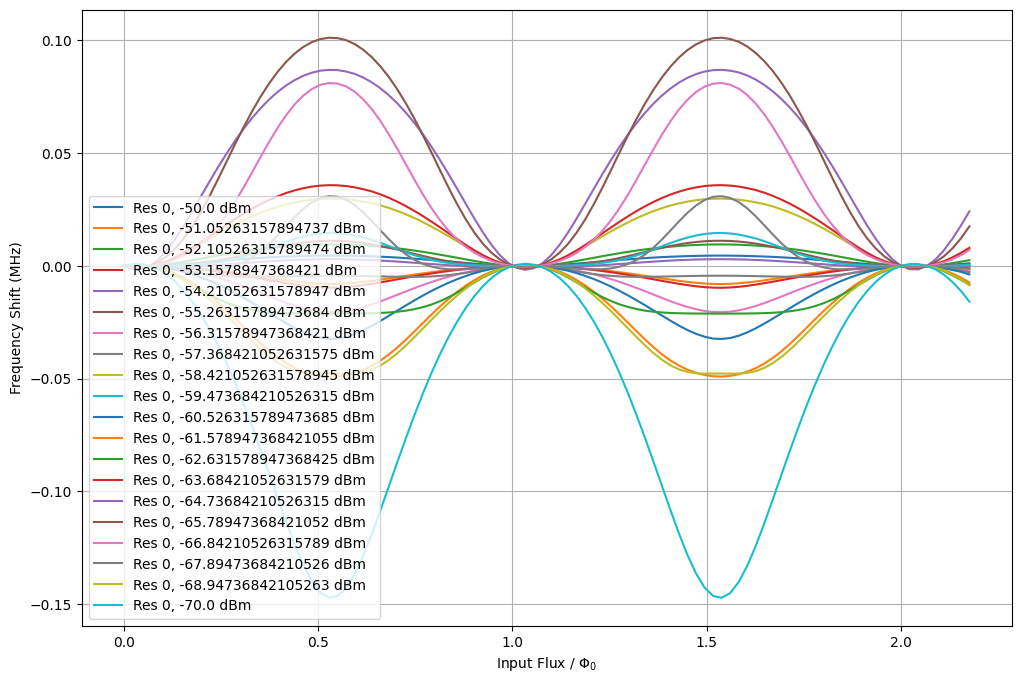

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- Experiment Setup ---
freqs_loaded = np.linspace(np.min(freqs_loaded), np.max(freqs_loaded), 2000)
# powers_dBm = [ -50, -65,-68, -70, -80]
powers_dBm = np.linspace(-50, -70, 20)
results_by_power = {}

# Define one set of flux steps
steps = 100 
max_current = 300e-6
I_array = np.linspace(0, max_current, steps)

channels = [comp for comp, mode in VNA.chain if isinstance(comp, Channel)]
num_channels = len(channels)

# --- Main Power Sweep Loop ---
for power_dBm in powers_dBm:
    print(f"--- Running simulation for P_rf = {power_dBm} dBm ---")
    VNA.P_rf = 10**(power_dBm / 10) / 1000

    # Baseline detection
    for squid in squids:
        squid.set_current("FluxRamp", 0.0)
    
    S_baseline = VNA.get_s_matrix(freqs_loaded)
    baseline_peaks_idx = find_all_peaks(freqs_loaded, S_baseline[1, 0])
    baseline_frs = freqs_loaded[baseline_peaks_idx]

    if len(baseline_frs) != num_channels:
        print(f"   Warning: Found {len(baseline_frs)} peaks. Skipping.")
        continue

    # Tracking sweep
    frs_data = np.zeros((steps, num_channels))
    current_guesses = np.copy(baseline_frs)

    for i, current in enumerate(I_array):
        for squid in squids:
            squid.set_current("FluxRamp", current)
            
        for c_idx, channel in enumerate(channels):
            frs_data[i, c_idx] = channel.get_resonance(f_guess=current_guesses[c_idx])
            current_guesses[c_idx] = frs_data[i, c_idx]
            
    results_by_power[power_dBm] = frs_data
    print(f"   Tracking complete for {power_dBm} dBm.")

# --- Plotting Results ---
plt.figure(figsize=(12, 8))
# Use I_array for x-axis scaling
try:
    M_ramp = squids[0].flux_lines["FluxRamp"].M
    x_axis_data = (I_array * M_ramp) / Phi0
    x_axis_label = "Input Flux / $\Phi_0$"
except (IndexError, KeyError):
    x_axis_data = I_array * 1e6
    x_axis_label = "Input Current (µA)"

for res_idx in range(min(1, num_channels)):
    for power_dBm in powers_dBm:
        fr_data = results_by_power.get(power_dBm)
        if fr_data is not None:
            y_data = 1e-6 * (fr_data[:, res_idx] - fr_data[0, res_idx])
            plt.plot(x_axis_data, y_data, label=f"Res {res_idx}, {power_dBm} dBm")

plt.xlabel(x_axis_label)
plt.ylabel("Frequency Shift (MHz)")
plt.legend()
plt.grid(True)
plt.show()


--- Plotting Maximum Signed Shift ---


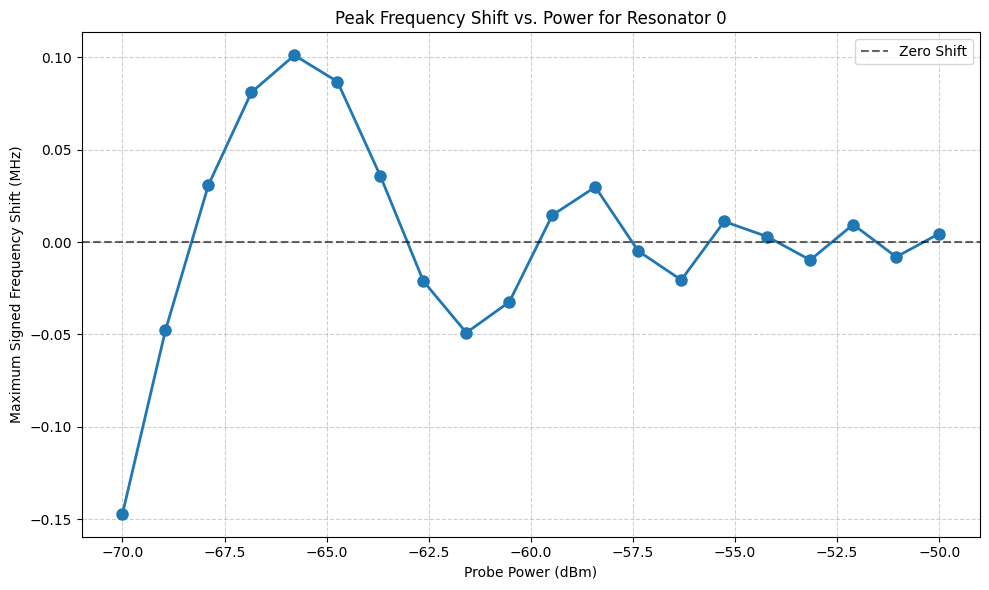

In [11]:
# --- Plotting Maximum Signed Shift Results ---
print("\n--- Plotting Maximum Signed Shift ---")
plt.figure(figsize=(10, 6))

# Assuming you want to track the first resonator (index 0)
res_idx = 0 

powers_plotted = []
max_signed_shifts = []

# Sort powers so the line plot connects points in order
for power_dBm in sorted(powers_dBm):
    fr_data = results_by_power.get(power_dBm)
    
    if fr_data is not None and res_idx < fr_data.shape[1]:
        # Calculate frequency shift (MHz)
        fr_no_flux = fr_data[0, res_idx]
        y_data = 1e-6 * (fr_data[:, res_idx] - fr_no_flux)
        
        # Find the index of the maximum absolute value
        max_abs_idx = np.argmax(np.abs(y_data))
        
        # Extract the value with its original sign
        signed_max = y_data[max_abs_idx]
        
        powers_plotted.append(power_dBm)
        max_signed_shifts.append(signed_max)

# Plotting
plt.plot(powers_plotted, max_signed_shifts, marker='o', linestyle='-', linewidth=2, markersize=8)

plt.axhline(0, color='black', linestyle='--', alpha=0.6, label='Zero Shift')

plt.xlabel("Probe Power (dBm)")
plt.ylabel("Maximum Signed Frequency Shift (MHz)")
plt.title(f"Peak Frequency Shift vs. Power for Resonator {res_idx}")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()